In [1]:
import pandas as pd

In [5]:
orders = pd.read_csv("data/clean/orders_master.csv")
items = pd.read_csv("data/clean/orders_items_clean.csv")

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month,delivery_days,...,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_order_value,payment_value,payment_installments,payment_type,review_score,is_repeat
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,8,...,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,38.71,1.0,credit_card,4.0,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,13,...,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,141.46,1.0,boleto,4.0,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,9,...,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,179.12,3.0,credit_card,5.0,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,13,...,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,72.20,1.0,credit_card,5.0,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,2,...,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,28.62,1.0,credit_card,5.0,0


is this business growing??
revenue and order count for each month

In [6]:
monthly = orders.groupby("order_month").agg(
    revenue = ("total_order_value", "sum"),
    order_count = ("order_id", "count")
)

monthly["mom_pct"] = monthly["revenue"].pct_change() * 100

monthly= monthly.loc["2017-01":"2018-08"]
monthly.round(1)

,revenue,order_count,mom_pct
order_month,,,
2017-01,127482.4,750,649657.2
2017-02,271239.3,1653,112.8
2017-03,414331.0,2546,52.8
2017-04,390812.4,2303,-5.7
2017-05,566657.4,3545,45.0
2017-06,490050.4,3135,-13.5
2017-07,566299.1,3872,15.6
2017-08,645832.4,4193,14.0
2017-09,701077.5,4150,8.6


<Axes: title={'center': 'Monthly Revenue'}, xlabel='order_month'>

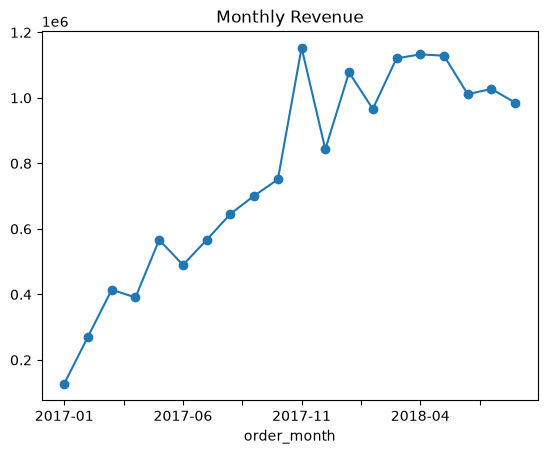

In [7]:
monthly["revenue"].plot(kind="line", marker="o", title="Monthly Revenue")

November 2017 shows the spike in the sales due to the black friday sales. Revenue climbs clearly from 127k in Jan 2017 to 1.15M in November 2017 at its peak.

Recommendation to plan stock ahead of November.



In [19]:
products = pd.read_csv("data/clean/products_clean.csv")

items = items.drop(columns=["product_category_name_english"], errors="ignore")
items = items.merge(
    products[["product_id", "product_category_name_english"]],
    on="product_id", how="left"
)

items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'total_price',
       'product_category_name', 'product_category_name_english'],
      dtype='str')

In [20]:
#revenue per category
cat = (items.groupby("product_category_name_english")["price"].sum().sort_values(
    ascending=False).to_frame("revenue")
)

cat["share_pct"] = cat["revenue"] / cat["revenue"].sum() * 100
cat["cumulative_pct"] = cat["share_pct"].cumsum()

top10 = cat.head(10)
top10.round(1)


,revenue,share_pct,cumulative_pct
product_category_name_english,,,
health_beauty,1233131.7,9.3,9.3
watches_gifts,1165899.0,8.8,18.1
bed_bath_table,1023434.8,7.7,25.9
sports_leisure,954673.6,7.2,33.1
computers_accessories,888613.6,6.7,39.8
furniture_decor,711927.7,5.4,45.2
housewares,615628.7,4.7,49.9
cool_stuff,610204.1,4.6,54.5
auto,578849.4,4.4,58.9


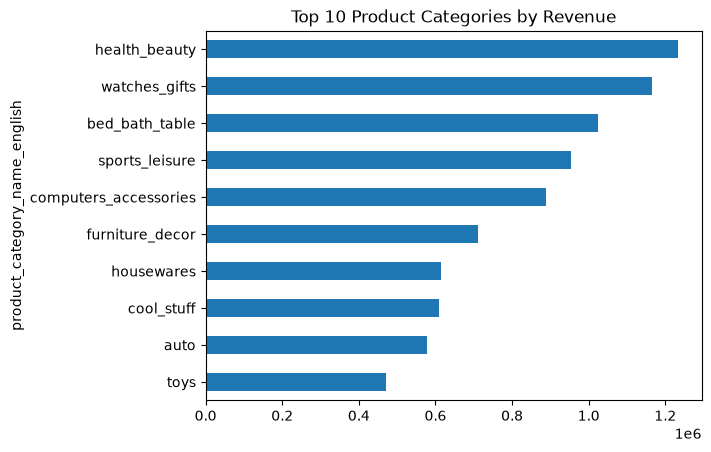

In [21]:
import matplotlib.pyplot as plt

top10["revenue"].sort_values().plot(kind="barh", title="Top 10 Product Categories by Revenue")
plt.show()

In [23]:
# how many categories does it take to reach 80% of revenue?
n_for_80 = (cat["cumulative_pct"] <= 80).sum() + 1
print("Categories needed for 80% of revenue:", n_for_80, "out of", len(cat))
print("Top 10 share:", round(top10["share_pct"].sum(), 1), "%")

Categories needed for 80% of revenue: 18 out of 72
Top 10 share: 62.4 %


In [24]:
# revenue, order count and average order value (AOV) for each customer state
state = orders.groupby("customer_state").agg(
    revenue=("total_order_value", "sum"),
    order_count=("order_id", "count"),
    aov=("total_order_value", "mean")
)

# each state's share of total revenue
state["share_pct"] = state["revenue"] / state["revenue"].sum() * 100

state = state.sort_values("revenue", ascending=False)
state.head(10).round(1)

,revenue,order_count,aov,share_pct
customer_state,,,,
SP,5768518.2,40494,142.5,37.4
RJ,2055401.6,12350,166.4,13.3
MG,1818891.7,11354,160.2,11.8
RS,861278.8,5344,161.2,5.6
PR,781708.8,4923,158.8,5.1
SC,595127.8,3546,167.8,3.9
BA,591137.8,3256,181.6,3.8
DF,346123.4,2080,166.4,2.2
GO,334212.4,1957,170.8,2.2


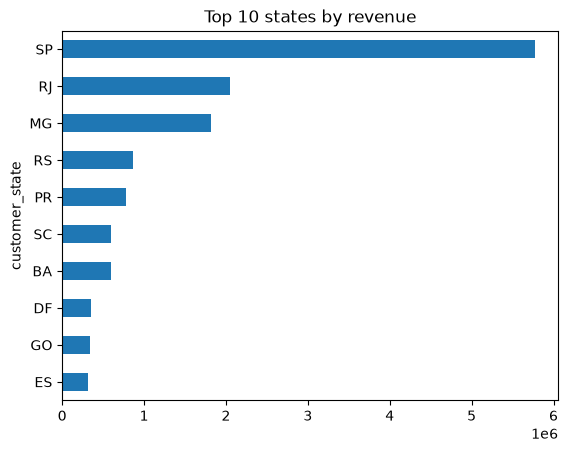

In [25]:
import matplotlib.pyplot as plt

state["revenue"].head(10).sort_values().plot(kind="barh", title="Top 10 states by revenue")
plt.show()

In [26]:
big_enough = state[state["order_count"] >= 100]
big_enough.sort_values("aov", ascending=False).head(5).round(1)

,revenue,order_count,aov,share_pct
customer_state,,,,
PB,137838.6,517,266.6,0.9
AL,94172.5,397,237.2,0.6
RO,56966.0,243,234.4,0.4
PA,212023.6,946,224.1,1.4
PI,105178.2,476,221.0,0.7


In [27]:
print("Top 3 states share of revenue:", round(state["share_pct"].head(3).sum(), 1), "%")

Top 3 states share of revenue: 62.5 %


The top three states (SP, RJ, MG) account for 62.5% of the revenue, while SP contributes 37.4%. 
The AOV is the lowest in SP (142.5) and the highest in smaller northern/ northeastern states such as PB (266.6), where the freight charges are quite high. Recommendations:
 Prioritize the core Southeastern markets, and consider implementing free shipping cutoffs to develop the high freight states.

In [28]:
# average review score and order count: on-time (0) vs late (1)
late_vs_ontime = orders.groupby("is_late").agg(
    avg_review=("review_score", "mean"),
    order_count=("order_id", "count"),
    avg_delivery_days=("delivery_days", "mean")
)
late_vs_ontime.round(2)

,avg_review,order_count,avg_delivery_days
is_late,,,
0,4.29,88644,10.42
1,2.57,7826,31.06


In [29]:
on_time = late_vs_ontime.loc[0, "avg_review"]
late = late_vs_ontime.loc[1, "avg_review"]
print("Review score drop for late orders:", round(on_time - late, 2), "points")
print("Late orders %:", round(orders["is_late"].mean() * 100, 2))

Review score drop for late orders: 1.73 points
Late orders %: 8.11


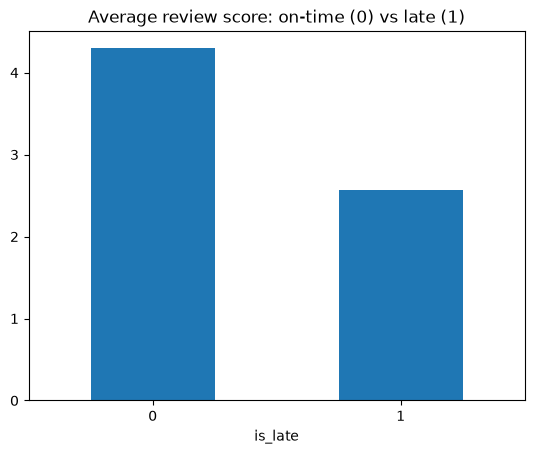

In [30]:
import matplotlib.pyplot as plt

late_vs_ontime["avg_review"].plot(kind="bar", title="Average review score: on-time (0) vs late (1)")
plt.xticks(rotation=0)
plt.show()

8.1% of orders (7,826) arrive late. Late orders average a 2.57 review score vs 4.29 for on-time orders, a drop of 1.72 points, and they take 31 days to arrive vs 10. Recommendation: focus on fixing delivery for the routes and states with the most late orders, and set more realistic delivery estimates so fewer customers are disappointed.

In [31]:
# analysing which state have delivery problems
# late %, average delivery days, and order count for each state
delivery = orders.groupby("customer_state").agg(
    late_pct=("is_late", "mean"),
    avg_delivery_days=("delivery_days", "mean"),
    avg_review=("review_score", "mean"),
    order_count=("order_id", "count")
)

# convert the late share to a percentage
delivery["late_pct"] = delivery["late_pct"] * 100

# worst states first, ignoring tiny states with few orders
delivery = delivery[delivery["order_count"] >= 100]
delivery = delivery.sort_values("late_pct", ascending=False)

delivery.head(10).round(1)

,late_pct,avg_delivery_days,avg_review,order_count
customer_state,,,,
AL,23.9,24.0,3.8,397
MA,19.7,21.1,3.8,717
PI,16.0,19.0,4.0,476
CE,15.3,20.8,3.9,1279
SE,15.2,21.0,3.9,335
BA,14.0,18.9,3.9,3256
RJ,13.5,14.8,4.0,12350
TO,12.8,17.2,4.2,274
PA,12.4,23.3,3.9,946


In [32]:
delivery.tail(5).round(1)

,late_pct,avg_delivery_days,avg_review,order_count
customer_state,,,,
SP,5.9,8.3,4.2,40494
MG,5.6,11.5,4.2,11354
PR,5.0,11.5,4.2,4923
AM,4.1,26.0,4.2,145
RO,2.9,18.9,4.2,243


In [33]:
# the 5 biggest states by orders, so you can see if the core markets are affected
delivery.sort_values("order_count", ascending=False).head(5).round(1)

,late_pct,avg_delivery_days,avg_review,order_count
customer_state,,,,
SP,5.9,8.3,4.2,40494
RJ,13.5,14.8,4.0,12350
MG,5.6,11.5,4.2,11354
RS,7.1,14.8,4.2,5344
PR,5.0,11.5,4.2,4923


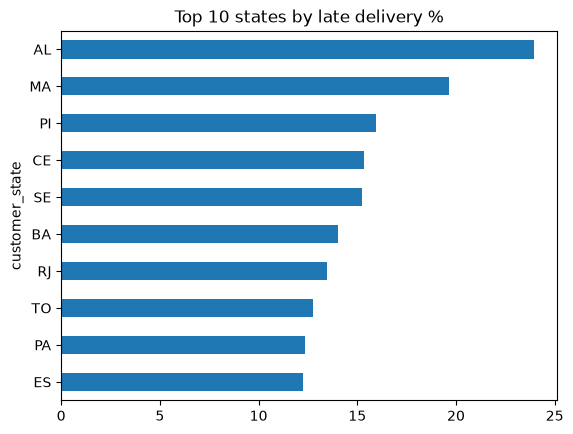

In [34]:
import matplotlib.pyplot as plt

delivery["late_pct"].head(10).sort_values().plot(kind="barh", title="Top 10 states by late delivery %")
plt.show()

Late delivery is worst in the northeast: AL (23.9%), MA (19.7%) and PI (16.0%), with review scores of 3.8 to 4.0 vs 4.2 in SP. By volume, RJ is the biggest problem: 13.5% late across 12,350 orders. Delivery time alone doesn't explain lateness. AM takes 26 days but only 4.1% are late because its estimates are more realistic. Recommendation: add regional carriers or fulfilment for the northeast and RJ, and set delivery estimates that match real delivery times.


In [35]:
cust = orders.groupby("customer_unique_id").agg(
    order_count=("order_id", "nunique"),
    total_spent=("total_order_value", "sum")
)
cust["is_repeat"] = cust["order_count"] > 1

total_customers = len(cust)
repeat_customers = cust["is_repeat"].sum()

print("Total customers:", total_customers)
print("Repeat customers:", repeat_customers)
print("Repeat customer %:", round(repeat_customers / total_customers * 100, 2))

Total customers: 93350
Repeat customers: 2801
Repeat customer %: 3.0


In [36]:
# share of total revenue from repeat customers
rev_by_type = cust.groupby("is_repeat")["total_spent"].sum()
print((rev_by_type / rev_by_type.sum() * 100).round(1))

# average spend per customer: one-time vs repeat
cust.groupby("is_repeat")["total_spent"].mean().round(1)

is_repeat
False    94.4
True      5.6
Name: total_spent, dtype: float64


is_repeat
False    160.7
True     308.5
Name: total_spent, dtype: float64

In [37]:
cust["order_count"].value_counts().sort_index()

order_count
1     90549
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64

In [38]:
first = orders.sort_values("order_purchase_timestamp").drop_duplicates("customer_unique_id", keep="first")

# repeat % by whether the first order was late (is_repeat is already in orders)
print(first.groupby("is_late")["is_repeat"].mean().mul(100).round(2))

# and by first-order review score
print(first.groupby("review_score")["is_repeat"].mean().mul(100).round(2))

is_late
0    3.05
1    2.49
Name: is_repeat, dtype: float64
review_score
1.0    2.84
2.0    2.86
3.0    2.90
4.0    2.76
5.0    3.12
Name: is_repeat, dtype: float64


Repeat rate: Only 3.0% of customers (2,801 of 93,350) ordered more than once, so 97% never came back.
Revenue share: Repeat customers bring just 5.6% of revenue, so the business depends on new customers.
Spend per customer: Repeat customers spend about 1.9x more (308.5 vs 160.7), so a second order is worth winning.
Late first order: Customers whose first order was late repeat slightly less (2.49% vs 3.05%), but the gap is small.
Repeat rate is flat across review scores (2.8% to 3.1%), so a bad first experience is not the main reason customers leave.

In [39]:
cat_f = items.groupby("product_category_name_english").agg(
    price=("price", "sum"),
    freight=("freight_value", "sum")
)

# shipping cost as a % of price
cat_f["freight_pct"] = cat_f["freight"] / cat_f["price"] * 100

# show the 10 categories where shipping is the biggest share
cat_f.sort_values("freight_pct", ascending=False).head(10)

,price,freight,freight_pct
product_category_name_english,,,
home_comfort_2,760.27,410.31,53.968985
flowers,1110.04,488.87,44.040755
furniture_mattress_and_upholstery,4323.38,1581.37,36.577169
christmas_supplies,8737.84,3190.91,36.518293
diapers_and_hygiene,1500.79,545.40,36.340860
cds_dvds_musicals,730.00,224.99,30.820548
signaling_and_security,21315.05,6477.54,30.389514
electronics,155043.93,45679.16,29.462076
food_drink,14942.88,4394.89,29.411265
